# Export anthropogenic heat
- This script is used to export anthropogenic heat.
- Simulations: CNTL, TranAlbe

In [1]:
import rasterio
from rasterio.windows import from_bounds
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
from rasterio.mask import mask
import pandas as pd
import numpy as np
import xarray as xr
home_path = '/gws/ssde/j25a/duicv/yuansun/'

In [2]:
hk_shapefile_path = f"{home_path}0_wrf-cstm_GM-HK/HK/mask/boundary/hk_boundary.shp"
gpd_hk = gpd.read_file(hk_shapefile_path)
gpd_hk = gpd_hk.to_crs(epsg=4326)
hk_bounds = gpd_hk.total_bounds  # minx, miny, maxx, maxy
print(hk_bounds)

[113.83506661  22.15334411 114.44199326  22.56194935]


In [3]:
ds_mask_hk = xr.open_dataset(f'{home_path}0_wrf-cstm_GM-HK/HK/mask/mask_HK_lat_lon.nc')
ds_mask_hk_pct_urban = ds_mask_hk['PCT_URBAN']
ds_mask_hk_urban_area = ds_mask_hk_pct_urban * 1.44 
ds_mask_hk_urban_area_total = ds_mask_hk_urban_area.sum().item()
print(ds_mask_hk_urban_area_total)

261.89304570370314


Scale: (1.0,)
Offset: (0.0,)
Units: (None,)
NoData: None
CRS: EPSG:4326


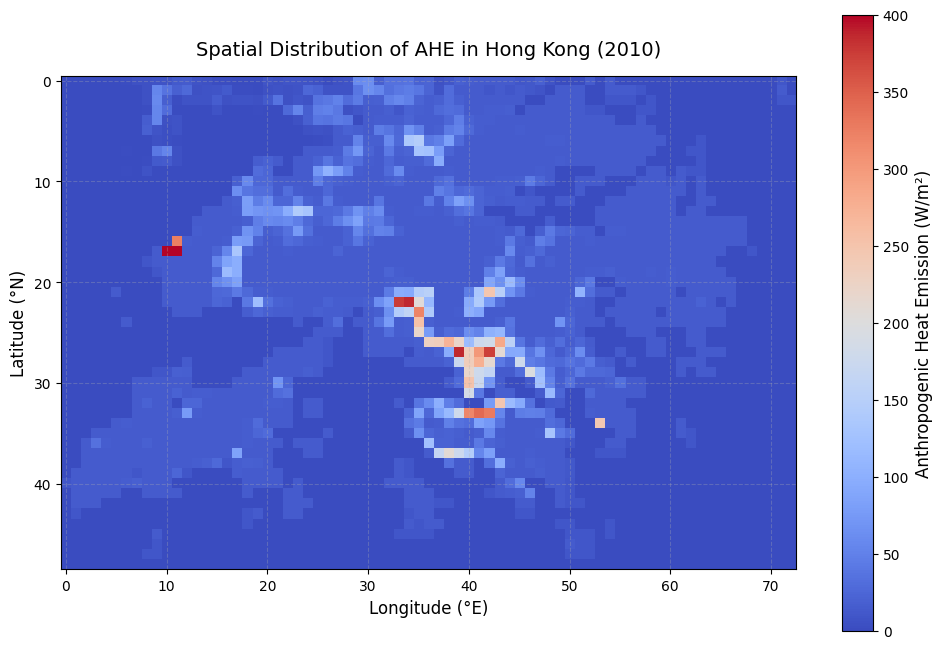

In [17]:
tif_path = f"{home_path}dataset/AH4GUC/version6/AHE_2010_year.tif"
with rasterio.open(tif_path) as src:
    window = from_bounds(*hk_bounds, transform=src.transform)
    hk_data_annual = src.read(1, window=window)
    hk_data_annual = hk_data_annual.astype('float32') / 100000.0  # Convert to W/m²
    hk_transform = src.window_transform(window)
    print("Scale:", src.scales)
    print("Offset:", src.offsets)
    print("Units:", src.units)
    print("NoData:", src.nodata)
    print("CRS:", src.crs)

plt.figure(figsize=(10, 8))
plt.imshow(hk_data_annual,cmap="coolwarm",aspect="equal",vmax=400)

# Add color bar with unit label
cbar = plt.colorbar(shrink=0.8)
cbar.set_label("Anthropogenic Heat Emission (W/m²)", fontsize=12)

# Add labels and title
plt.title("Spatial Distribution of AHE in Hong Kong (2010)", fontsize=14, pad=15)
plt.xlabel("Longitude (°E)", fontsize=12)
plt.ylabel("Latitude (°N)", fontsize=12)
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()    

Scale: (1.0,)
Offset: (0.0,)
Units: (None,)
NoData: None
CRS: EPSG:4326


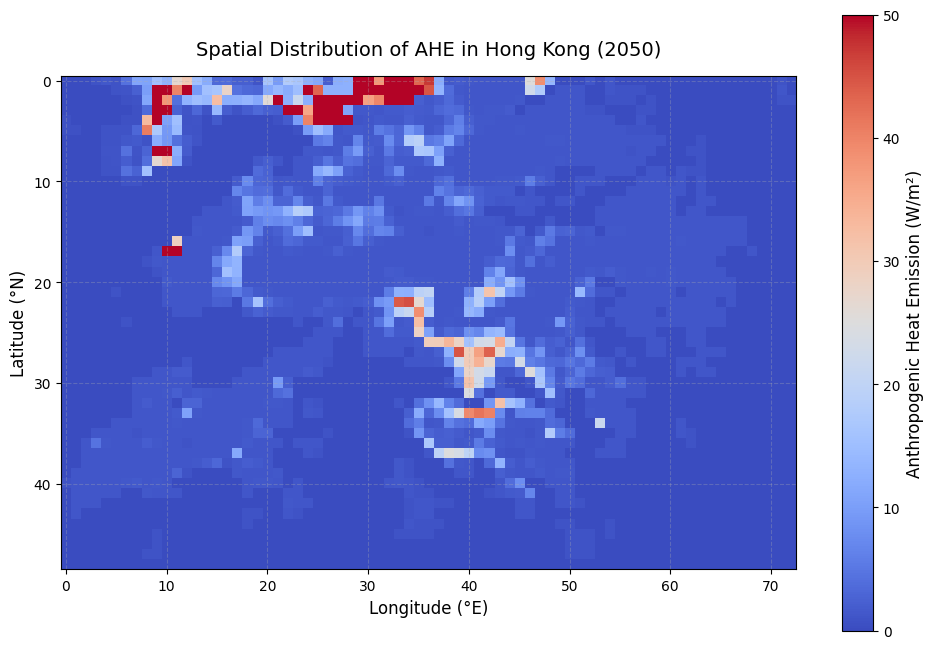

In [15]:
tif_path = f"{home_path}dataset/AH4GUC/version6/AHE_2050_year.tif"
with rasterio.open(tif_path) as src:
    window = from_bounds(*hk_bounds, transform=src.transform)
    hk_data_annual = src.read(1, window=window)
    hk_data_annual = hk_data_annual.astype('float32') / 100000.0  # Convert to W/m²
    hk_transform = src.window_transform(window)
    print("Scale:", src.scales)
    print("Offset:", src.offsets)
    print("Units:", src.units)
    print("NoData:", src.nodata)
    print("CRS:", src.crs)

plt.figure(figsize=(10, 8))
plt.imshow(hk_data_annual,cmap="coolwarm",aspect="equal", vmax=50)

# Add color bar with unit label
cbar = plt.colorbar(shrink=0.8)
cbar.set_label("Anthropogenic Heat Emission (W/m²)", fontsize=12)

# Add labels and title
plt.title("Spatial Distribution of AHE in Hong Kong (2050)", fontsize=14, pad=15)
plt.xlabel("Longitude (°E)", fontsize=12)
plt.ylabel("Latitude (°N)", fontsize=12)
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()    

In [ ]:
ahf_hk_monthly = []
sum_ahf_hk_monthly = []
for m in range(1, 13):
    monthly_tif_path = f"{home_path}dataset/AH4GUC/version6/AHE_2010_{m:02d}_average.tif"
    with rasterio.open(monthly_tif_path) as src:
        geometries = gpd_hk.geometry.values
        hk_data, hk_transform = mask(src,geometries,crop=True,nodata=src.nodata)
        hk_data = hk_data[0].astype("float32") / 100000.0  # factor, W/m²
        #max_val = np.nanmax(hk_data)
        #hk_data_masked = np.where(hk_data == max_val, 0, hk_data)
        ahf_hk_monthly.append(hk_data.mean().item())
        if m in [1, 3, 5, 7, 8, 10, 12]:
            days = 31
        elif m == 2:
            days = 28
        else:
            days = 30        
        area_sum = (hk_data * (days*24)).sum()  # W/m² * m² * hours in month, convert to megawatt-hour
        sum_ahf_hk_monthly.append(area_sum.item())
sum_ahf_hk_monthly       

[31953108.0,
 28063712.0,
 30993726.0,
 30873984.0,
 34282120.0,
 34525572.0,
 35460384.0,
 35715728.0,
 34145068.0,
 34114020.0,
 30646020.0,
 32286474.0]

In [5]:
ahf_hk_monthly

[11.60749340057373,
 11.286885261535645,
 11.25898265838623,
 11.589334487915039,
 12.453545570373535,
 12.960050582885742,
 12.881568908691406,
 12.974326133728027,
 12.817216873168945,
 12.392480850219727,
 11.503761291503906,
 11.728593826293945]

In [9]:
np.mean(ahf_hk_monthly)

np.float64(12.12118665377299)

In [6]:
with rasterio.open(f"{home_path}dataset/AH4GUC/version6/AHE_2010_year.tif") as year_src_2010:
    geometries = gpd_hk.geometry.values
    hk_ahf_year_2010, hk_transform = mask(year_src_2010,geometries,crop=True,nodata=src.nodata)
    hk_ahf_year_2010 = hk_ahf_year_2010[0].astype("float32") / 100000.0  # W/m²
    print(np.round(hk_ahf_year_2010.mean(),2)) 

11.73


In [10]:
with rasterio.open(f"{home_path}dataset/AH4GUC/version6/AHE_2050_year.tif") as year_src_2050:
    geometries = gpd_hk.geometry.values
    hk_ahf_year_2050, hk_transform = mask(year_src_2050,geometries,crop=True,nodata=src.nodata)
    hk_ahf_year_2050 = hk_ahf_year_2050[0].astype("float32") / 100000.0  # W/m²
    print(np.round(hk_ahf_year_2050.mean(),2)) 

1.33


In [4]:
region = 'HK'
annual_ahf = []
for scenario in ['cntl', 'tran_albe']:
    simulation_filename = f'../energy_consumption/data_for_figure/building_energy_consumption_{region}_{scenario}.csv'
    df_scenario = pd.read_csv(simulation_filename)
    #df_scenario_heat = df_scenario[df_scenario['var']=='URBAN_HEAT']
    #df_scenario_wasteheat = df_scenario[df_scenario['var']=='WASTEHEAT']
    df_subset = df_scenario[df_scenario['var'].isin(['URBAN_HEAT', 'WASTEHEAT'])]
    df_pivot = df_subset.pivot_table(index='time', columns='var', values='value (unit:W e6)', aggfunc='sum')
    df_pivot = df_pivot.fillna(0)
    df_pivot['TOTAL_HEAT'] = df_pivot['URBAN_HEAT'] + df_pivot['WASTEHEAT']
    df_total = df_pivot[['TOTAL_HEAT']].reset_index()
    df_total['time'] = pd.to_datetime(df_total['time'])
    df_total_clean = df_total[df_total['time'].dt.year >2034].copy()
    df_total_clean['year'] = df_total_clean['time'].dt.year
    df_total_clean_yearly = df_total_clean.groupby('year')['TOTAL_HEAT'].sum().reset_index()
    df_total_clean_yearly_normalize = df_total_clean.groupby('year')['TOTAL_HEAT'].mean().reset_index()
    df_total_clean_yearly_normalize['TOTAL_HEAT'] = df_total_clean_yearly_normalize['TOTAL_HEAT'] / ds_mask_hk_urban_area_total
    df_total_clean_yearly_normalize['scenario'] = scenario
    annual_ahf.append(df_total_clean_yearly_normalize)
df_annual_ahf = pd.concat(annual_ahf, axis=0)  
df_annual_ahf # unit: W/m2

,year,TOTAL_HEAT,scenario
0,2035,3.184190,cntl
1,2036,2.971466,cntl
2,2037,2.931711,cntl
3,2038,3.154571,cntl
4,2039,2.920336,cntl
0,2035,3.497937,tran_albe
1,2036,2.956903,tran_albe
2,2037,2.890029,tran_albe
3,2038,3.110888,tran_albe
4,2039,2.854491,tran_albe


In [6]:
df_wide = df_annual_ahf.pivot(
    index='year',
    columns='scenario',
    values='TOTAL_HEAT'
)

df_wide['contrast'] = df_wide['tran_albe'] - df_wide['cntl']
print(df_wide)

scenario      cntl  tran_albe  contrast
year                                   
2035      3.184190   3.497937  0.313747
2036      2.971466   2.956903 -0.014562
2037      2.931711   2.890029 -0.041681
2038      3.154571   3.110888 -0.043684
2039      2.920336   2.854491 -0.065845


In [7]:
ds_cntl = xr.open_dataset(f'{home_path}0_wrf-cstm_GM-HK/runs/TranUrbAlb_HK/runs/d04_tran_albe/archive_ctsm/lnd/tran_albe4.clm2.h1.2038-08-18-00000.nc')
ds_cntl_ahf = ds_cntl['URBAN_HEAT'] + ds_cntl['WASTEHEAT']
ds_cntl_ahf

<xarray.DataArray (time: 5, lat: 60, lon: 60)> Size: 72kB
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,  0.       ,
          0.       ,  0.       ],
        [       nan, 23.814753 , 15.288818 , ...,  0.       ,
          0.       ,  0.       ],
        [       nan, 19.895584 ,  8.239559 , ...,  0.       ,
          0.       ,  0.       ]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [       nan,        nan,        nan, ...,  0.       ,
          0.       ,  0.       ],
        [       nan, 17.16644  , 11.295195 , ...,  0.       ,
          0.       ,  0.       ],
        [       nan, 15.749168 ,  6.7066536, ...,  0.       ,
          0.       ,  0.       ]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,  0.       ,
          0.       ,  0.       ],
        [       nan, 17.779245 , 11.295192 , ...,  0.       ,
          0.       ,  0.       ],
        [       nan, 15.185492 ,  6.408959 , ...,  0.       ,
          0.       ,  0.       ]]], shape=(5, 60, 60), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 40B 2038-08-17T12:00:00 ... 2038-08-21T12:...
  * lon      (lon) float32 240B 113.8 113.8 113.8 113.8 ... 114.4 114.5 114.5
  * lat      (lat) float32 240B 22.06 22.07 22.08 22.09 ... 22.67 22.68 22.69

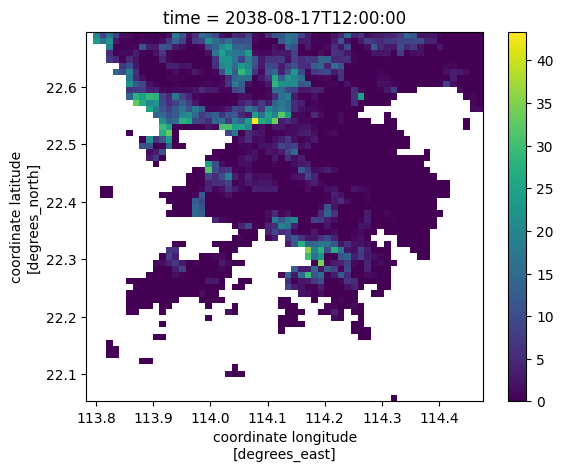

In [8]:
ds_cntl_ahf[0].plot()